In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import os, pickle, random

import uuid
from dataclasses import dataclass, field
from datetime    import datetime, timedelta
from typing      import List, Optional, Dict, Tuple

from sklearn.preprocessing   import OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.pipeline        import Pipeline
from sklearn.compose         import ColumnTransformer
from sklearn.ensemble        import RandomForestRegressor
from sklearn.metrics         import mean_absolute_error, mean_squared_error, r2_score


matplotlib.rcParams['figure.dpi'] = 120
SEED = 42

# Data Preprocessing
**Intelligent Court Hearing Scheduling System**

This notebook loads the synthetic dataset, applies preprocessing steps, and
prepares the train/test splits for model training.

**Preprocessing steps**
1. Load and inspect dataset
2. Drop non-ML columns (`case_id`, `courtroom_id`, `hearing_date`, `judge_id`)
3. Ordinal-encode categorical features (`case_type`, `priority`)
4. Standard-scale numeric features (`num_parties`, `judge_idx`)
5. Stratified 70/30 train/test split by `case_type`

In [2]:
#Load Dataset
df = pd.read_csv("data/nigerian_court_cases.csv")
df.head()

,case_id,case_type,num_parties,priority,judge_id,judge_idx,courtroom_id,hearing_date,hearing_duration_mins
0,CASE00001,Criminal,4,Low,J006,5,CR02,2024-10-09,167
1,CASE00002,Criminal,4,High,J002,1,CR04,2024-05-23,274
2,CASE00003,Constitutional,9,Medium,J002,1,CR02,2025-08-28,201
3,CASE00004,Commercial,3,Low,J004,3,CR01,2024-02-01,127
4,CASE00005,Civil,5,High,J001,0,CR04,2024-08-27,119


In [3]:
CATEGORICAL_FTS = ["case_type", "priority"]
NUMERIC_FTS     = ["num_parties", "judge_idx"]
ALL_FEATURES    = CATEGORICAL_FTS + NUMERIC_FTS
TARGET          = "hearing_duration_mins"

EXCLUDED = ["case_id", "judge_id", "courtroom_id", "hearing_date"]

X = df[ALL_FEATURES]
y = df[TARGET]

print("Feature matrix shape :", X.shape)
print("Target variable shape :", y.shape)
print("\nFeature dtypes:")
print(X.dtypes)

Feature matrix shape : (5000, 4)
Target variable shape : (5000,)

Feature dtypes:
case_type      object
priority       object
num_parties     int64
judge_idx       int64
dtype: object


In [4]:
print("case_type levels :", sorted(df["case_type"].unique()))
print("priority levels  :", sorted(df["priority"].unique()))
print("\nCase-type counts:")
print(df["case_type"].value_counts())

case_type levels : ['Civil', 'Commercial', 'Constitutional', 'Criminal', 'Family', 'Labour', 'Land']
priority levels  : ['High', 'Low', 'Medium']

Case-type counts:
case_type
Civil             1419
Criminal          1131
Commercial         757
Family             752
Land               398
Constitutional     352
Labour             191
Name: count, dtype: int64


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.30,
    random_state = SEED,
    stratify     = df["case_type"]
)

print(f"Training set  : {X_train.shape[0]:,} records ({X_train.shape[0]/len(df)*100:.0f}%)")
print(f"Test set      : {X_test.shape[0]:,} records  ({X_test.shape[0]/len(df)*100:.0f}%)")

Training set  : 3,500 records (70%)
Test set      : 1,500 records  (30%)


In [6]:
train_dist = X_train["case_type"].value_counts(normalize=True).sort_index()
test_dist  = X_test["case_type"].value_counts(normalize=True).sort_index()

dist_check = pd.DataFrame({
    "Train %": (train_dist * 100).round(1),
    "Test %":  (test_dist  * 100).round(1),
})
print("Case-type distribution across splits (should be similar):")
display(dist_check)

Case-type distribution across splits (should be similar):


,Train %,Test %
case_type,,
Civil,28.4,28.4
Commercial,15.1,15.1
Constitutional,7.0,7.1
Criminal,22.6,22.6
Family,15.0,15.1
Labour,3.8,3.8
Land,8.0,7.9


### Build preprocessing pipeline

In [7]:
CASE_TYPES = ["Civil","Criminal","Family","Commercial","Constitutional","Land","Labour"]
PRIORITIES = ["Low","Medium","High"]

categorical_transformer = OrdinalEncoder(
    categories          = [CASE_TYPES, PRIORITIES],
    handle_unknown      = "use_encoded_value",
    unknown_value       = -1
)
numeric_transformer = StandardScaler()

preprocessor = ColumnTransformer(transformers=[
    ("cat", categorical_transformer, CATEGORICAL_FTS),
    ("num", numeric_transformer,     NUMERIC_FTS),
], remainder="drop")

print("Preprocessor built.")
print(preprocessor)

Preprocessor built.
ColumnTransformer(transformers=[('cat',
                                 OrdinalEncoder(categories=[['Civil',
                                                             'Criminal',
                                                             'Family',
                                                             'Commercial',
                                                             'Constitutional',
                                                             'Land', 'Labour'],
                                                            ['Low', 'Medium',
                                                             'High']],
                                                handle_unknown='use_encoded_value',
                                                unknown_value=-1),
                                 ['case_type', 'priority']),
                                ('num', StandardScaler(),
                                 ['num_parties', 'judge_idx'])])


In [8]:
X_train_t = preprocessor.fit_transform(X_train)
X_test_t  = preprocessor.transform(X_test)

print("Transformed training shape:", X_train_t.shape)
print("\nFirst 3 rows (case_type_enc, priority_enc, num_parties_scaled, judge_idx_scaled):")
print(X_train_t[:3].round(3))

Transformed training shape: (3500, 4)

First 3 rows (case_type_enc, priority_enc, num_parties_scaled, judge_idx_scaled):
[[ 3.     0.    -0.545 -1.556]
 [ 0.     2.     0.482 -0.249]
 [ 0.     1.    -0.032  1.494]]


Feature correlations with hearing_duration_mins:
num_parties    0.438
priority       0.145
case_type      0.137
judge_idx     -0.111
Name: hearing_duration_mins, dtype: float64


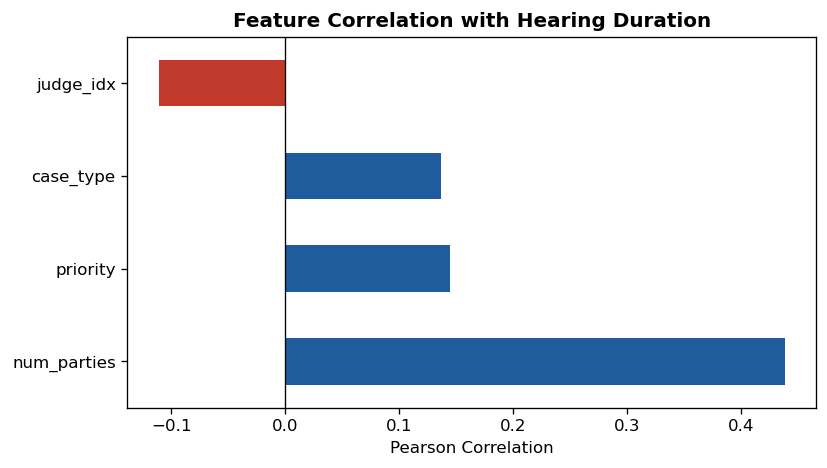

In [9]:
X_train_df = pd.DataFrame(X_train_t, columns=ALL_FEATURES)
X_train_df[TARGET] = y_train.values

corr = X_train_df.corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
print("Feature correlations with hearing_duration_mins:")
print(corr.round(3))

fig, ax = plt.subplots(figsize=(7, 4))
corr.plot(kind="barh", ax=ax, color=["#1F5C9E" if v > 0 else "#C0392B" for v in corr])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Feature Correlation with Hearing Duration", fontweight="bold")
ax.set_xlabel("Pearson Correlation")
plt.tight_layout()
plt.show()

In [10]:
os.makedirs("models", exist_ok=True)

with open("models/preprocessor.pkl", "wb") as f:
    pickle.dump(preprocessor, f)

np.save("models/X_train.npy", X_train_t)
np.save("models/X_test.npy",  X_test_t)
np.save("models/y_train.npy", y_train.values)
np.save("models/y_test.npy",  y_test.values)
X_test.to_csv("models/X_test_raw.csv", index=False)

# Model Training & Evaluation
**Intelligent Court Hearing Scheduling System**

This notebook trains the Random Forest regression model using the preprocessed
splits from Notebook 02, performs hyperparameter optimisation with
`RandomizedSearchCV`, evaluates on the held-out test set, and serialises the
final pipeline.

**Metrics**
- **MAE** – Mean Absolute Error (primary; directly interpretable in minutes)
- **RMSE** – Root Mean Square Error
- **R²** – Coefficient of determination


In [11]:
# Load preprocessed data
X_train = np.load("models/X_train.npy")
X_test  = np.load("models/X_test.npy")
y_train = np.load("models/y_train.npy")
y_test  = np.load("models/y_test.npy")
X_test_raw = pd.read_csv("models/X_test_raw.csv")

print(f"Training set   : {X_train.shape}")
print(f"Test set       : {X_test.shape}")
print(f"Target (train) : mean={y_train.mean():.1f}  std={y_train.std():.1f}")

Training set   : (3500, 4)
Test set       : (1500, 4)
Target (train) : mean=125.6  std=63.4


In [12]:
CASE_TYPES      = ["Civil","Criminal","Family","Commercial","Constitutional","Land","Labour"]
PRIORITIES      = ["Low","Medium","High"]
CATEGORICAL_FTS = ["case_type","priority"]
NUMERIC_FTS     = ["num_parties","judge_idx"]
ALL_FEATURES    = CATEGORICAL_FTS + NUMERIC_FTS
TARGET          = "hearing_duration_mins"

categorical_transformer = OrdinalEncoder(
    categories     = [CASE_TYPES, PRIORITIES],
    handle_unknown = "use_encoded_value",
    unknown_value  = -1
)
numeric_transformer = StandardScaler()

preprocessor = ColumnTransformer(transformers=[
    ("cat", categorical_transformer, CATEGORICAL_FTS),
    ("num", numeric_transformer,     NUMERIC_FTS),
], remainder="drop")

rf = RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=-1)

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor",    rf),
])

print("Full pipeline constructed:")
print(pipeline)

Full pipeline constructed:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OrdinalEncoder(categories=[['Civil',
                                                                              'Criminal',
                                                                              'Family',
                                                                              'Commercial',
                                                                              'Constitutional',
                                                                              'Land',
                                                                              'Labour'],
                                                                             ['Low',
                                                                              'Medium',
                                                                              'Hig

In [13]:
df = pd.read_csv("data/nigerian_court_cases.csv")
X  = df[ALL_FEATURES]
y  = df[TARGET]

X_train_raw, X_test_raw2, y_train_raw, y_test_raw = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=df["case_type"]
)

print(f"Train: {X_train_raw.shape[0]:,}  |  Test: {X_test_raw2.shape[0]:,}")

Train: 3,500  |  Test: 1,500


In [14]:
PARAM_GRID = {
    "regressor__n_estimators":      [100, 200, 300, 500],
    "regressor__max_depth":         [None, 10, 20, 30],
    "regressor__min_samples_split": [2, 5, 10],
    "regressor__min_samples_leaf":  [1, 2, 4],
    "regressor__max_features":      ["sqrt", "log2", 0.8],
}

search = RandomizedSearchCV(
    estimator            = pipeline,
    param_distributions  = PARAM_GRID,
    n_iter               = 30,
    cv                   = 5,
    scoring              = "neg_mean_absolute_error",
    verbose              = 1,
    random_state         = SEED,
    n_jobs               = -1,
    refit                = True,
)

search.fit(X_train_raw, y_train_raw)

for k, v in search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nBest CV MAE: {-search.best_score_:.2f} mins")

best_pipeline = search.best_estimator_

Fitting 5 folds for each of 30 candidates, totalling 150 fits
  regressor__n_estimators: 200
  regressor__min_samples_split: 5
  regressor__min_samples_leaf: 4
  regressor__max_features: log2
  regressor__max_depth: 10

Best CV MAE: 35.95 mins


CV MAE per fold : [np.float64(37.61), np.float64(35.43), np.float64(35.83), np.float64(36.33), np.float64(34.54)]
Mean CV MAE     : 35.95 mins
Std  CV MAE     : 1.02 mins


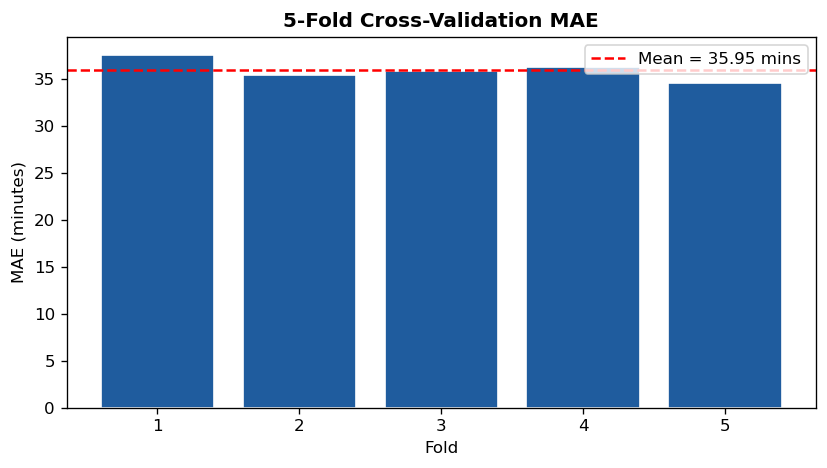

In [15]:
cv_scores = -cross_val_score(
    best_pipeline, X_train_raw, y_train_raw,
    cv=5, scoring="neg_mean_absolute_error", n_jobs=-1
)

print(f"CV MAE per fold : {[round(v,2) for v in cv_scores]}")
print(f"Mean CV MAE     : {cv_scores.mean():.2f} mins")
print(f"Std  CV MAE     : {cv_scores.std():.2f} mins")

# Plot
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(1, 6), cv_scores, color="#1F5C9E", edgecolor="white")
ax.axhline(cv_scores.mean(), color="red", linestyle="--",
           label=f"Mean = {cv_scores.mean():.2f} mins")
ax.set_xticks(range(1, 6))
ax.set_xlabel("Fold")
ax.set_ylabel("MAE (minutes)")
ax.set_title("5-Fold Cross-Validation MAE", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

In [16]:
y_pred = best_pipeline.predict(X_test_raw2)

mae  = mean_absolute_error(y_test_raw, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_raw, y_pred))
r2   = r2_score(y_test_raw, y_pred)

print("  TEST SET EVALUATION RESULTS")
print(f"  MAE  (Mean Absolute Error)  : {mae:.2f} mins")
print(f"  RMSE (Root Mean Sq. Error)  : {rmse:.2f} mins")
print(f"  R²   (Coefficient of Det.)  : {r2:.4f}")


  TEST SET EVALUATION RESULTS
  MAE  (Mean Absolute Error)  : 35.36 mins
  RMSE (Root Mean Sq. Error)  : 47.98 mins
  R²   (Coefficient of Det.)  : 0.4325


Per-Case-Type MAE:


,MAE (mins),N
Case Type,,
Civil,23.63,426
Commercial,43.41,227
Constitutional,64.12,106
Criminal,48.69,339
Family,22.08,226
Labour,21.18,57
Land,30.35,119


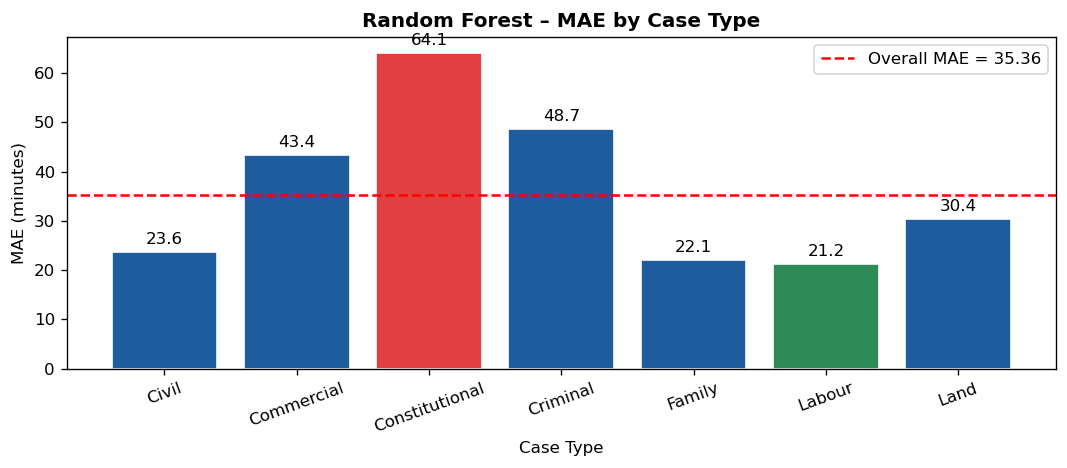

In [17]:
results = []
for ct in sorted(X_test_raw2["case_type"].unique()):
    mask    = X_test_raw2["case_type"] == ct
    ct_mae  = mean_absolute_error(y_test_raw[mask], y_pred[mask])
    results.append({"Case Type": ct, "MAE (mins)": round(ct_mae, 2), "N": mask.sum()})

mae_df = pd.DataFrame(results).set_index("Case Type")
print("Per-Case-Type MAE:")
display(mae_df)

# Plot
fig, ax = plt.subplots(figsize=(9, 4))
colors = ["#E04040" if v == mae_df["MAE (mins)"].max()
          else "#2E8B57" if v == mae_df["MAE (mins)"].min()
          else "#1F5C9E" for v in mae_df["MAE (mins)"]]
bars = ax.bar(mae_df.index, mae_df["MAE (mins)"], color=colors, edgecolor="white")
ax.bar_label(bars, fmt="%.1f", padding=3)
ax.axhline(mae, color="red", linestyle="--", label=f"Overall MAE = {mae:.2f}")
ax.set_title("Random Forest – MAE by Case Type", fontweight="bold")
ax.set_xlabel("Case Type")
ax.set_ylabel("MAE (minutes)")
ax.tick_params(axis="x", rotation=20)
ax.legend()
plt.tight_layout()
plt.show()

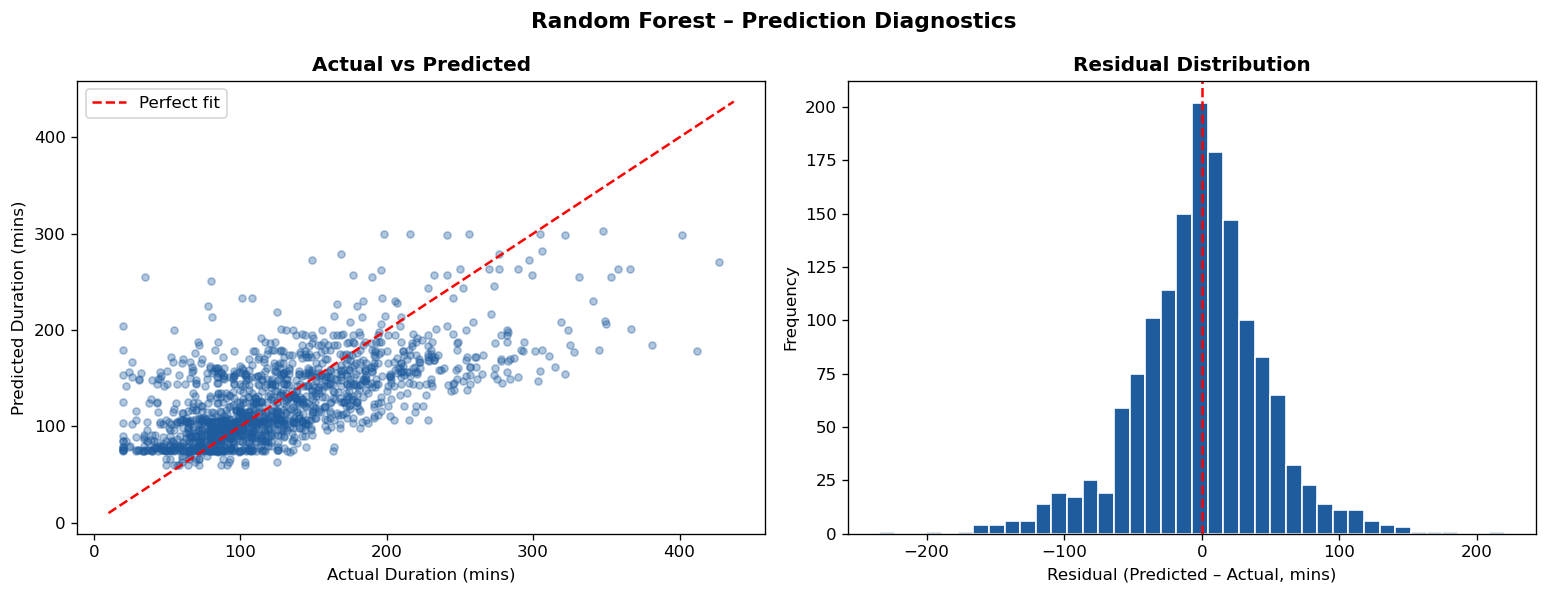

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter
ax = axes[0]
ax.scatter(y_test_raw, y_pred, alpha=0.35, s=18, color="#1F5C9E")
lims = [min(y_test_raw.min(), y_pred.min())-10,
        max(y_test_raw.max(), y_pred.max())+10]
ax.plot(lims, lims, "r--", linewidth=1.5, label="Perfect fit")
ax.set_xlabel("Actual Duration (mins)")
ax.set_ylabel("Predicted Duration (mins)")
ax.set_title("Actual vs Predicted", fontweight="bold")
ax.legend()

# Residuals
ax2 = axes[1]
residuals = y_pred - y_test_raw
ax2.hist(residuals, bins=40, color="#1F5C9E", edgecolor="white")
ax2.axvline(0, color="red", linestyle="--", linewidth=1.5)
ax2.set_xlabel("Residual (Predicted – Actual, mins)")
ax2.set_ylabel("Frequency")
ax2.set_title("Residual Distribution", fontweight="bold")

plt.suptitle("Random Forest – Prediction Diagnostics", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

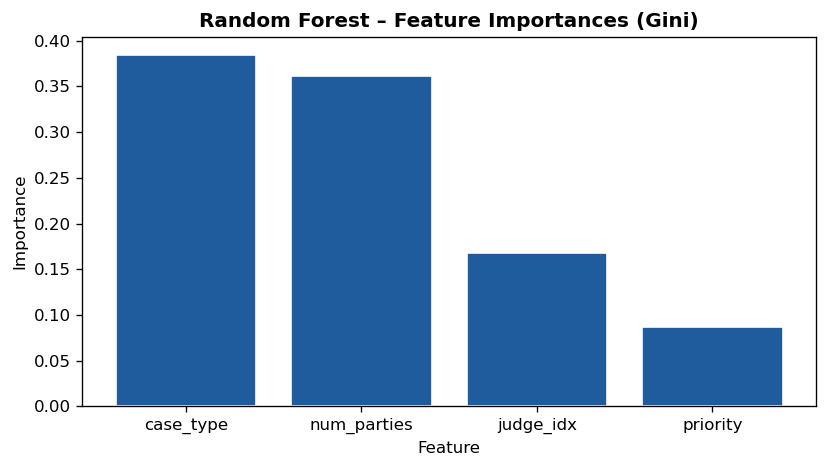

Feature importances:
  case_type     : 0.3847
  num_parties   : 0.3613
  judge_idx     : 0.1674
  priority      : 0.0866


In [19]:
rf_model  = best_pipeline.named_steps["regressor"]
imps      = rf_model.feature_importances_
feat_names = ["case_type","priority","num_parties","judge_idx"]
sorted_idx = np.argsort(imps)[::-1]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([feat_names[i] for i in sorted_idx],
       [imps[i] for i in sorted_idx],
       color="#1F5C9E", edgecolor="white")
ax.set_title("Random Forest – Feature Importances (Gini)", fontweight="bold")
ax.set_xlabel("Feature")
ax.set_ylabel("Importance")
plt.tight_layout()
plt.show()

print("Feature importances:")
for i in sorted_idx:
    print(f"  {feat_names[i]:<14}: {imps[i]:.4f}")

In [20]:
os.makedirs("models", exist_ok=True)
model_path = "models/rf_duration_model.pkl"
with open(model_path, "wb") as f:
    pickle.dump(best_pipeline, f)

print(f"Model saved → {model_path}")

Model saved → models/rf_duration_model.pkl


# Rule-Based Constraint Engine
**Intelligent Court Hearing Scheduling System**

This notebook implements and demonstrates the rule-based constraint engine.
The engine enforces four hard scheduling constraints in sequence:

| Constraint | Rule |
|---|---|
| **C3 – Judge Specialisation** | Case type must match judge's legal specialisation |
| **C4 – Courtroom Capacity**   | Number of parties ≤ courtroom capacity |
| **C1 – Judge Availability**   | Judge must have no overlapping confirmed hearings |
| **C2 – Courtroom Availability** | Courtroom must be free for the full predicted window |


In [21]:
@dataclass
class Judge:
    judge_id:        str
    name:            str
    specialisations: List[str]

@dataclass
class Courtroom:
    room_id:   str
    name:      str
    capacity:  int
    is_active: bool = True

@dataclass
class HearingRequest:
    case_id:            str
    case_type:          str
    num_parties:        int
    priority:           str
    judge_id:           str
    courtroom_id:       str
    proposed_start:     datetime
    predicted_duration: int       # minutes (from Random Forest model)

    @property
    def proposed_end(self):
        return self.proposed_start + timedelta(minutes=self.predicted_duration)

@dataclass
class ConfirmedHearing:
    slot_id:      str
    case_id:      str
    case_type:    str
    judge_id:     str
    courtroom_id: str
    start_time:   datetime
    end_time:     datetime
    duration_mins: int

@dataclass
class PendingEntry:
    queue_id:        str
    case_id:         str
    conflict_reason: str
    flagged_at:      datetime

@dataclass
class SchedulingResult:
    success:              bool
    confirmed:            Optional[ConfirmedHearing] = None
    pending:              Optional[PendingEntry]     = None
    violated_constraint:  Optional[str]              = None

In [22]:
class ConstraintEngine:
    """
    In-memory rule-based constraint enforcement engine.
    Enforces C3 → C4 → C1 → C2 in sequence for every hearing request.
    """

    def __init__(self, judges=None, courtrooms=None):
        self.judges = judges or {
            "J001": Judge("J001","Justice Adeyemi",   ["Civil","Commercial","Land"]),
            "J002": Judge("J002","Justice Okonkwo",   ["Criminal","Constitutional"]),
            "J003": Judge("J003","Justice Babatunde", ["Family","Labour","Civil"]),
            "J004": Judge("J004","Justice Eze",       ["Commercial","Civil","Land"]),
            "J005": Judge("J005","Justice Nwosu",     ["Criminal","Labour"]),
            "J006": Judge("J006","Justice Aliyu",     ["Constitutional","Criminal","Civil"]),
            "J007": Judge("J007","Justice Afolabi",   ["Family","Labour","Commercial"]),
            "J008": Judge("J008","Justice Danjuma",   ["Land","Civil","Family"]),
        }
        self.courtrooms = courtrooms or {
            "CR01": Courtroom("CR01","Courtroom 1", 12),
            "CR02": Courtroom("CR02","Courtroom 2",  8),
            "CR03": Courtroom("CR03","Courtroom 3", 15),
            "CR04": Courtroom("CR04","Courtroom 4",  6),
            "CR05": Courtroom("CR05","Courtroom 5", 10),
            "CR06": Courtroom("CR06","Courtroom 6", 20),
            "CR07": Courtroom("CR07","Courtroom 7",  8),
            "CR08": Courtroom("CR08","Courtroom 8", 12),
        }
        self.timetable: List[ConfirmedHearing] = []
        self.pending_queue: List[PendingEntry]  = []

    def _overlaps(self, s1, e1, s2, e2):
        return s1 < e2 and s2 < e1

    def _check_specialisation(self, judge_id, case_type):
        j = self.judges.get(judge_id)
        if j is None:
            return False, f"Judge {judge_id} not found."
        if case_type not in j.specialisations:
            return False, (f"Judge {judge_id} ({j.name}) not specialised in "
                           f"'{case_type}'. Specialisations: {j.specialisations}.")
        return True, None

    def _check_capacity(self, room_id, num_parties):
        r = self.courtrooms.get(room_id)
        if r is None:
            return False, f"Courtroom {room_id} not found."
        if not r.is_active:
            return False, f"Courtroom {room_id} is inactive."
        if num_parties > r.capacity:
            return False, (f"Courtroom {room_id} (capacity {r.capacity}) too small "
                           f"for {num_parties} parties.")
        return True, None

    def _check_judge_free(self, judge_id, start, end):
        for h in self.timetable:
            if h.judge_id == judge_id and self._overlaps(start, end, h.start_time, h.end_time):
                return False, (f"Judge {judge_id} has confirmed hearing {h.case_id} "
                               f"{h.start_time:%H:%M}–{h.end_time:%H:%M}.")
        return True, None

    def _check_room_free(self, room_id, start, end):
        for h in self.timetable:
            if h.courtroom_id == room_id and self._overlaps(start, end, h.start_time, h.end_time):
                return False, (f"Courtroom {room_id} booked for case {h.case_id} "
                               f"{h.start_time:%H:%M}–{h.end_time:%H:%M}.")
        return True, None

    def schedule(self, req: HearingRequest) -> SchedulingResult:
        end = req.proposed_end

        # C3 – Specialisation
        ok, reason = self._check_specialisation(req.judge_id, req.case_type)
        if not ok: return self._reject(req, f"[C3 – Specialisation] {reason}")

        # C4 – Capacity
        ok, reason = self._check_capacity(req.courtroom_id, req.num_parties)
        if not ok: return self._reject(req, f"[C4 – Capacity] {reason}")

        # C1 – Judge availability
        ok, reason = self._check_judge_free(req.judge_id, req.proposed_start, end)
        if not ok: return self._reject(req, f"[C1 – Judge Availability] {reason}")

        # C2 – Courtroom availability
        ok, reason = self._check_room_free(req.courtroom_id, req.proposed_start, end)
        if not ok: return self._reject(req, f"[C2 – Courtroom Availability] {reason}")

        # All constraints pass → CONFIRM
        confirmed = ConfirmedHearing(
            slot_id=str(uuid.uuid4()), case_id=req.case_id, case_type=req.case_type,
            judge_id=req.judge_id, courtroom_id=req.courtroom_id,
            start_time=req.proposed_start, end_time=end,
            duration_mins=req.predicted_duration,
        )
        self.timetable.append(confirmed)
        return SchedulingResult(success=True, confirmed=confirmed)

    def _reject(self, req, reason):
        entry = PendingEntry(
            queue_id=str(uuid.uuid4()), case_id=req.case_id,
            conflict_reason=reason, flagged_at=datetime.now()
        )
        self.pending_queue.append(entry)
        return SchedulingResult(success=False, pending=entry, violated_constraint=reason)

    def conflict_rate(self):
        total = len(self.timetable) + len(self.pending_queue)
        return len(self.pending_queue) / total if total else 0.0

In [23]:
#Demo: schedule a set of test cases
engine    = ConstraintEngine()
base_time = datetime(2025, 9, 1, 9, 0)

test_cases = [
    # (case_id, type,          parties, priority, judge, room, offset_mins, duration)
    ("C001", "Civil",          3, "High",   "J001", "CR01", 0,   90),
    ("C002", "Criminal",       5, "High",   "J002", "CR02", 0,  120),
    ("C003", "Family",         2, "Medium", "J003", "CR03", 0,   60),
    ("C004", "Commercial",     4, "Medium", "J004", "CR05", 0,   75),
    # C1 conflict: J001 busy 09:00–10:30 (C001)
    ("C005", "Civil",          3, "Low",    "J001", "CR06", 30,  60),
    # C2 conflict: CR02 busy 09:00–11:00 (C002)
    ("C006", "Criminal",       6, "Medium", "J005", "CR02", 60,  45),
    # C3 conflict: J003 not specialised in Constitutional
    ("C007", "Constitutional", 7, "High",   "J003", "CR07", 300,150),
    # C4 conflict: CR04 capacity=6, requesting 20 parties
    ("C008", "Land",          20, "Medium", "J008", "CR04", 200, 80),
    # Valid: J002 free at 13:00
    ("C009", "Criminal",       3, "Low",    "J002", "CR07", 240, 55),
]

rows = []
for tc in test_cases:
    req = HearingRequest(
        case_id=tc[0], case_type=tc[1], num_parties=tc[2], priority=tc[3],
        judge_id=tc[4], courtroom_id=tc[5],
        proposed_start=base_time + timedelta(minutes=tc[6]),
        predicted_duration=tc[7],
    )
    result = engine.schedule(req)
    rows.append({
        "Case ID":   tc[0],
        "Type":      tc[1],
        "Judge":     tc[4],
        "Room":      tc[5],
        "Status":    "CONFIRMED" if result.success else "CONFLICT",
        "Reason / Slot": (f"{req.proposed_start:%H:%M}–{req.proposed_end:%H:%M}"
                          if result.success else result.violated_constraint[:60]),
    })

display(pd.DataFrame(rows))
print(f"\nConflict rate: {engine.conflict_rate()*100:.1f}%")

,Case ID,Type,Judge,Room,Status,Reason / Slot
0,C001,Civil,J001,CR01,CONFIRMED,09:00–10:30
1,C002,Criminal,J002,CR02,CONFIRMED,09:00–11:00
2,C003,Family,J003,CR03,CONFIRMED,09:00–10:00
3,C004,Commercial,J004,CR05,CONFIRMED,09:00–10:15
4,C005,Civil,J001,CR06,CONFLICT,[C1 – Judge Availability] Judge J001 has confi...
5,C006,Criminal,J005,CR02,CONFLICT,[C2 – Courtroom Availability] Courtroom CR02 b...
6,C007,Constitutional,J003,CR07,CONFLICT,[C3 – Specialisation] Judge J003 (Justice Baba...
7,C008,Land,J008,CR04,CONFLICT,[C4 – Capacity] Courtroom CR04 (capacity 6) to...
8,C009,Criminal,J002,CR07,CONFIRMED,13:00–13:55



Conflict rate: 44.4%


In [24]:
# Confirmed timetable

timetable_rows = [{
    "Slot ID":     h.slot_id[:8] + "...",
    "Case ID":     h.case_id,
    "Type":        h.case_type,
    "Judge":       h.judge_id,
    "Room":        h.courtroom_id,
    "Start":       h.start_time.strftime("%H:%M"),
    "End":         h.end_time.strftime("%H:%M"),
    "Duration":    f"{h.duration_mins} mins",
} for h in engine.timetable]

print(f"Confirmed hearings: {len(engine.timetable)}")
display(pd.DataFrame(timetable_rows))

Confirmed hearings: 5


,Slot ID,Case ID,Type,Judge,Room,Start,End,Duration
0,98f18791...,C001,Civil,J001,CR01,09:00,10:30,90 mins
1,8433fa46...,C002,Criminal,J002,CR02,09:00,11:00,120 mins
2,2462ba28...,C003,Family,J003,CR03,09:00,10:00,60 mins
3,9598c99f...,C004,Commercial,J004,CR05,09:00,10:15,75 mins
4,1189ebee...,C009,Criminal,J002,CR07,13:00,13:55,55 mins


# System Evaluation
**Intelligent Court Hearing Scheduling System**

This notebook evaluates the full integrated system using two metrics:

1. **MAE** – Mean Absolute Error on ML duration predictions (per case type)
2. **SCR** – Scheduling Conflict Rate
   - *AI System*: ML-predicted durations + constraint engine
   - *Baseline*: Fixed 90-minute slots + constraint engine (simulates manual scheduling)


In [25]:
np.random.seed(SEED)
random.seed(SEED)

In [26]:
with open("models/rf_duration_model.pkl", "rb") as f:
    model = pickle.load(f)

df = pd.read_csv("data/nigerian_court_cases.csv")

CATEGORICAL_FTS = ["case_type","priority"]
NUMERIC_FTS     = ["num_parties","judge_idx"]
ALL_FEATURES    = CATEGORICAL_FTS + NUMERIC_FTS
TARGET          = "hearing_duration_mins"

X = df[ALL_FEATURES]
y = df[TARGET]

_, X_test, _, y_test = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=df["case_type"]
)

y_pred = model.predict(X_test)
print(f"Test set size: {len(X_test):,}")


Test set size: 1,500


In [27]:
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("  SECTION A – ML PREDICTION ACCURACY")
print(f"  MAE  : {mae:.2f} mins")
print(f"  RMSE : {rmse:.2f} mins")
print(f"  R²   : {r2:.4f}")

  SECTION A – ML PREDICTION ACCURACY
  MAE  : 35.36 mins
  RMSE : 47.98 mins
  R²   : 0.4325


,MAE (mins),N (test)
Case Type,,
Civil,23.63,426
Commercial,43.41,227
Constitutional,64.12,106
Criminal,48.69,339
Family,22.08,226
Labour,21.18,57
Land,30.35,119


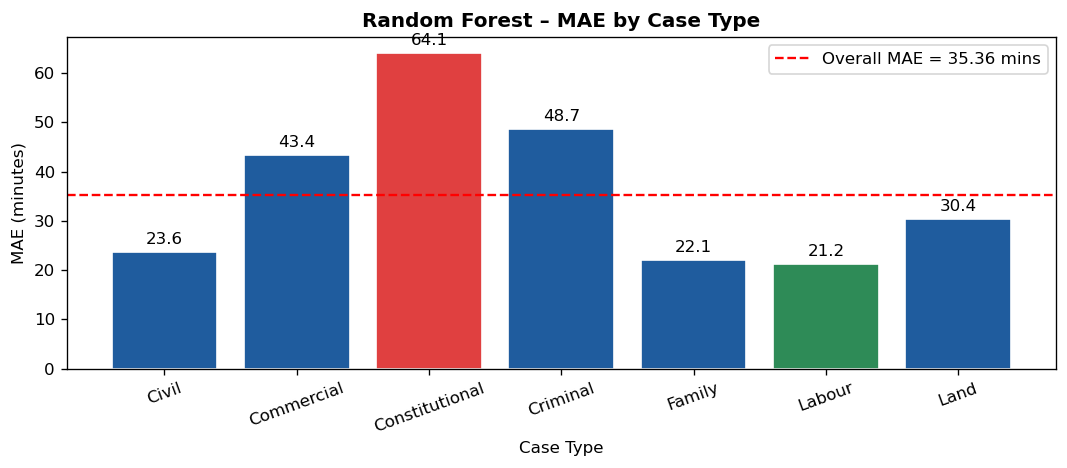

In [28]:
mae_rows = []
for ct in sorted(X_test["case_type"].unique()):
    mask   = X_test["case_type"] == ct
    ct_mae = mean_absolute_error(y_test[mask], y_pred[mask])
    mae_rows.append({"Case Type": ct, "MAE (mins)": round(ct_mae,2), "N (test)": int(mask.sum())})

mae_df = pd.DataFrame(mae_rows).set_index("Case Type")
display(mae_df)

# Plot
fig, ax = plt.subplots(figsize=(9, 4))
colors = ["#E04040" if v == mae_df["MAE (mins)"].max()
          else "#2E8B57" if v == mae_df["MAE (mins)"].min()
          else "#1F5C9E" for v in mae_df["MAE (mins)"]]
bars = ax.bar(mae_df.index, mae_df["MAE (mins)"], color=colors, edgecolor="white")
ax.bar_label(bars, fmt="%.1f", padding=3)
ax.axhline(mae, color="red", linestyle="--", linewidth=1.4,
           label=f"Overall MAE = {mae:.2f} mins")
ax.set_title("Random Forest – MAE by Case Type", fontweight="bold")
ax.set_xlabel("Case Type"); ax.set_ylabel("MAE (minutes)")
ax.tick_params(axis="x", rotation=20); ax.legend()
plt.tight_layout(); plt.show()

In [29]:
@dataclass
class Judge:
    judge_id: str; name: str; specialisations: List[str]

@dataclass
class Courtroom:
    room_id: str; name: str; capacity: int; is_active: bool = True

@dataclass
class HearingRequest:
    case_id: str; case_type: str; num_parties: int; priority: str
    judge_id: str; courtroom_id: str; proposed_start: datetime
    predicted_duration: int
    @property
    def proposed_end(self): return self.proposed_start + timedelta(minutes=self.predicted_duration)

@dataclass
class ConfirmedHearing:
    slot_id: str; case_id: str; case_type: str; judge_id: str
    courtroom_id: str; start_time: datetime; end_time: datetime; duration_mins: int

@dataclass
class PendingEntry:
    queue_id: str; case_id: str; conflict_reason: str; flagged_at: datetime

@dataclass
class SchedulingResult:
    success: bool; confirmed: Optional[ConfirmedHearing]=None
    pending: Optional[PendingEntry]=None; violated_constraint: Optional[str]=None

class ConstraintEngine:
    def __init__(self):
        self.judges = {
            "J001":Judge("J001","Justice Adeyemi",   ["Civil","Commercial","Land"]),
            "J002":Judge("J002","Justice Okonkwo",   ["Criminal","Constitutional"]),
            "J003":Judge("J003","Justice Babatunde", ["Family","Labour","Civil"]),
            "J004":Judge("J004","Justice Eze",       ["Commercial","Civil","Land"]),
            "J005":Judge("J005","Justice Nwosu",     ["Criminal","Labour"]),
            "J006":Judge("J006","Justice Aliyu",     ["Constitutional","Criminal","Civil"]),
            "J007":Judge("J007","Justice Afolabi",   ["Family","Labour","Commercial"]),
            "J008":Judge("J008","Justice Danjuma",   ["Land","Civil","Family"]),
        }
        self.courtrooms = {
            "CR01":Courtroom("CR01","Courtroom 1",12), "CR02":Courtroom("CR02","Courtroom 2",8),
            "CR03":Courtroom("CR03","Courtroom 3",15), "CR04":Courtroom("CR04","Courtroom 4",6),
            "CR05":Courtroom("CR05","Courtroom 5",10), "CR06":Courtroom("CR06","Courtroom 6",20),
            "CR07":Courtroom("CR07","Courtroom 7",8),  "CR08":Courtroom("CR08","Courtroom 8",12),
        }
        self.timetable=[]; self.pending_queue=[]

    def _overlaps(self,s1,e1,s2,e2): return s1<e2 and s2<e1
    def schedule(self, req):
        end=req.proposed_end
        j=self.judges.get(req.judge_id)
        if not j or req.case_type not in j.specialisations:
            return self._reject(req,f"[C3] Specialisation mismatch.")
        r=self.courtrooms.get(req.courtroom_id)
        if not r or not r.is_active or req.num_parties>r.capacity:
            return self._reject(req,f"[C4] Capacity/inactive.")
        for h in self.timetable:
            if h.judge_id==req.judge_id and self._overlaps(req.proposed_start,end,h.start_time,h.end_time):
                return self._reject(req,f"[C1] Judge overlap.")
        for h in self.timetable:
            if h.courtroom_id==req.courtroom_id and self._overlaps(req.proposed_start,end,h.start_time,h.end_time):
                return self._reject(req,f"[C2] Room overlap.")
        c=ConfirmedHearing(str(uuid.uuid4()),req.case_id,req.case_type,
            req.judge_id,req.courtroom_id,req.proposed_start,end,req.predicted_duration)
        self.timetable.append(c); return SchedulingResult(success=True,confirmed=c)
    def _reject(self,req,reason):
        e=PendingEntry(str(uuid.uuid4()),req.case_id,reason,datetime.now())
        self.pending_queue.append(e)
        return SchedulingResult(success=False,pending=e,violated_constraint=reason)
    def conflict_rate(self):
        t=len(self.timetable)+len(self.pending_queue)
        return len(self.pending_queue)/t if t else 0.0

In [30]:
JUDGE_SPEC = {
    "J001":["Civil","Commercial","Land"],   "J002":["Criminal","Constitutional"],
    "J003":["Family","Labour","Civil"],     "J004":["Commercial","Civil","Land"],
    "J005":["Criminal","Labour"],           "J006":["Constitutional","Criminal","Civil"],
    "J007":["Family","Labour","Commercial"],"J008":["Land","Civil","Family"],
}
CASE_TYPES = ["Civil","Criminal","Family","Commercial","Constitutional","Land","Labour"]
ROOM_IDS   = [f"CR{str(i).zfill(2)}" for i in range(1, 9)]
PRIORITIES = ["High","Medium","Low"]
BASELINE   = 90    # fixed slot length used by manual scheduling (mins)
N_SIM      = 200

def build_case_queue(n, seed_val):
    """Build an identical case list used by both simulations."""
    np.random.seed(seed_val); random.seed(seed_val)
    cases = []
    for i in range(n):
        ct       = np.random.choice(CASE_TYPES)
        eligible = [j for j, specs in JUDGE_SPEC.items() if ct in specs]
        judge    = random.choice(eligible)
        room     = random.choice(ROOM_IDS)
        parties  = np.random.randint(2, 8)
        pri      = np.random.choice(PRIORITIES)
        judge_idx= list(JUDGE_SPEC.keys()).index(judge)
        cases.append(dict(case_id=f"SIM{i:04d}", case_type=ct,
                          num_parties=parties, priority=pri,
                          judge_id=judge, courtroom_id=room,
                          judge_idx=judge_idx))
    return cases

def run_sim(cases, use_ml=True):
    """
    Schedule all cases and count confirmed vs conflicted.
    use_ml=True  → AI system  (ML-predicted durations)
    use_ml=False → Baseline   (fixed 90-min slots)
    """
    np.random.seed(SEED); random.seed(SEED)
    engine = ConstraintEngine()
    base_date = datetime(2025, 9, 1, 8, 0)

    # AI tracks actual hearing end per judge/room (accurate cursor)
    judge_actual_end = {jid: base_date for jid in JUDGE_SPEC}
    room_actual_end  = {rid: base_date for rid in ROOM_IDS}
    # Baseline tracks clerk diary end (advances by BASELINE only)
    judge_clerk_end  = {jid: base_date for jid in JUDGE_SPEC}

    for case in cases:
        ct, pri       = case["case_type"], case["priority"]
        judge, room   = case["judge_id"],  case["courtroom_id"]
        parties       = case["num_parties"]
        judge_idx     = case["judge_idx"]

        # Predict / assign duration
        if use_ml:
            row = pd.DataFrame([{"case_type": ct, "priority": pri,
                                  "num_parties": parties, "judge_idx": judge_idx}])
            dur = int(np.clip(round(model.predict(row)[0]), 10, 480))
        else:
            dur = BASELINE

        # Proposed start time
        if use_ml:
            # AI: proposes after both judge AND room are free
            proposed_start = max(judge_actual_end[judge], room_actual_end[room])
        else:
            # Baseline clerk: just opens the next fixed diary slot for the judge
            proposed_start = judge_clerk_end[judge]

        req = HearingRequest(
            case_id=case["case_id"], case_type=ct, num_parties=parties,
            priority=pri, judge_id=judge, courtroom_id=room,
            proposed_start=proposed_start, predicted_duration=dur,
        )
        result = engine.schedule(req)

        if result.success:
            actual_end = result.confirmed.end_time
            judge_actual_end[judge] = actual_end
            room_actual_end[room]   = actual_end
            judge_clerk_end[judge]  = proposed_start + timedelta(minutes=BASELINE)
        else:
            judge_actual_end[judge] = proposed_start + timedelta(minutes=dur)
            room_actual_end[room]   = proposed_start + timedelta(minutes=dur)
            judge_clerk_end[judge]  = proposed_start + timedelta(minutes=BASELINE)

    return {
        "confirmed": len(engine.timetable),
        "conflicts": len(engine.pending_queue),
        "total":     N_SIM,
        "scr_pct":   round(engine.conflict_rate() * 100, 2),
    }

# Build identical case queue for both systems
cases = build_case_queue(N_SIM, SEED)

print("Running AI System simulation (ML-predicted durations)...")
ai_res   = run_sim(cases, use_ml=True)

print("Running Baseline simulation (fixed 90-min slots)...")
base_res = run_sim(cases, use_ml=False)

print(f"\nAI System → SCR: {ai_res['scr_pct']}%  ({ai_res['conflicts']}/{N_SIM} conflicts)")
print(f"Baseline  → SCR: {base_res['scr_pct']}%  ({base_res['conflicts']}/{N_SIM} conflicts)")
print(f"Improvement: Δ {base_res['scr_pct'] - ai_res['scr_pct']:.1f} percentage points")


Running AI System simulation (ML-predicted durations)...
Running Baseline simulation (fixed 90-min slots)...

AI System → SCR: 2.0%  (4/200 conflicts)
Baseline  → SCR: 30.0%  (60/200 conflicts)
Improvement: Δ 28.0 percentage points


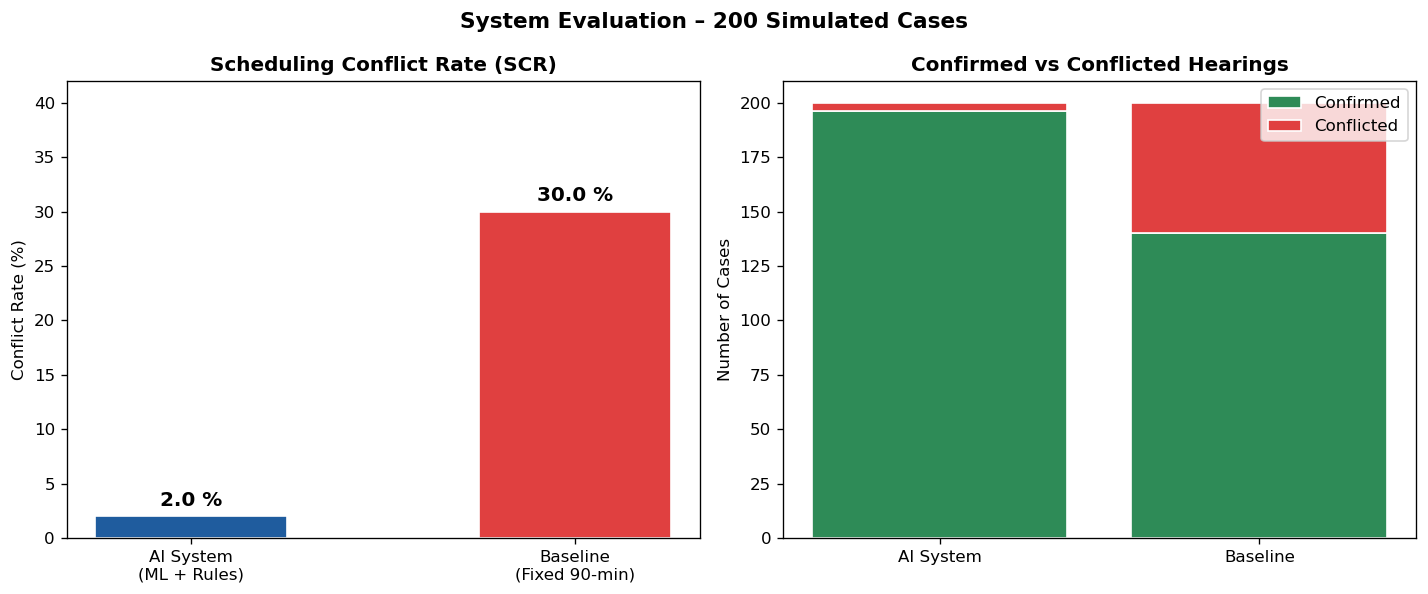

In [31]:
# ── SCR comparison plots ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart: conflict rate
ax = axes[0]
labels = ["AI System\n(ML + Rules)", "Baseline\n(Fixed 90-min)"]
scrs   = [ai_res["scr_pct"], base_res["scr_pct"]]
bars   = ax.bar(labels, scrs, color=["#1F5C9E", "#E04040"],
                edgecolor="white", width=0.5)
ax.bar_label(bars, fmt="%.1f %%", padding=4, fontsize=12, fontweight="bold")
ax.set_title("Scheduling Conflict Rate (SCR)", fontweight="bold")
ax.set_ylabel("Conflict Rate (%)")
ax.set_ylim(0, max(scrs) * 1.4)

# Stacked bar: confirmed vs conflicted
ax2 = axes[1]
x = np.arange(2)
ax2.bar(x, [ai_res["confirmed"], base_res["confirmed"]],
        color="#2E8B57", label="Confirmed", edgecolor="white")
ax2.bar(x, [ai_res["conflicts"], base_res["conflicts"]],
        bottom=[ai_res["confirmed"], base_res["confirmed"]],
        color="#E04040", label="Conflicted", edgecolor="white")
ax2.set_xticks(x)
ax2.set_xticklabels(["AI System", "Baseline"])
ax2.set_title("Confirmed vs Conflicted Hearings", fontweight="bold")
ax2.set_ylabel("Number of Cases")
ax2.legend()

plt.suptitle(f"System Evaluation – {N_SIM} Simulated Cases",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


In [32]:
# ── Final evaluation summary table ───────────────────────────────────────────
summary = pd.DataFrame({
    "Metric":  [
        "MAE (mins)", "RMSE (mins)", "R²",
        "SCR – AI System (%)", "SCR – Baseline (%)",
        "SCR Improvement (pp)"
    ],
    "Value": [
        round(mae, 2), round(rmse, 2), round(r2, 4),
        ai_res["scr_pct"], base_res["scr_pct"],
        round(base_res["scr_pct"] - ai_res["scr_pct"], 2)
    ],
    "Interpretation": [
        "Avg. slot sizing error (minutes)",
        "Root mean square prediction error",
        "Proportion of duration variance explained",
        f"{ai_res['conflicts']} conflicts out of {N_SIM} attempts",
        f"{base_res['conflicts']} conflicts out of {N_SIM} attempts",
        "Fewer conflicts with AI vs manual scheduling"
    ]
})
display(summary)
print(f"\nConclusion: The AI system reduced the scheduling conflict rate by "
      f"{base_res['scr_pct'] - ai_res['scr_pct']:.1f} percentage points "
      f"compared to fixed-slot manual scheduling, from "
      f"{base_res['scr_pct']}% down to {ai_res['scr_pct']}%.")


,Metric,Value,Interpretation
0,MAE (mins),35.3600,Avg. slot sizing error (minutes)
1,RMSE (mins),47.9800,Root mean square prediction error
2,R²,0.4325,Proportion of duration variance explained
3,SCR – AI System (%),2.0000,4 conflicts out of 200 attempts
4,SCR – Baseline (%),30.0000,60 conflicts out of 200 attempts
5,SCR Improvement (pp),28.0000,Fewer conflicts with AI vs manual scheduling



Conclusion: The AI system reduced the scheduling conflict rate by 28.0 percentage points compared to fixed-slot manual scheduling, from 30.0% down to 2.0%.
